# M01. Weather Factors

### Imports

In [1]:
from U01Imports import *
from U02Functions import *
from U03Classes import *
from U04Datasets import *
from U05Models import *

Using device: cuda


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Settings

In [3]:
# Training window
min_training_date = '20180101'
max_training_date = '20260630'

# Testing (out-of-sample) window — bounded, used for all OOS wOBA evaluation
min_testing_date  = '20250101'
max_testing_date  = '20260630'

ensemble_size = 10           # Number of classifiers in the model ensemble
n_random_states = 10         # Number of random-seed runs per torch_config; best run (by AvgRank) is kept
run_daily_weather = True     # Add today's weather to create WFX (Set to True during season)
train_weather_model = True   # Train weather factor model
if "is_main" not in globals():
    is_main = True

In [4]:
print("Training weather models:", train_weather_model and is_main)

Training weather models: True


### Data

##### Plate Appearances

In [5]:
pa_dataset = pd.read_csv(os.path.join(baseball_path, "PA Dataset.csv"))

##### Open Meteo

In [6]:
open_meteo_column_list = ['game_id', 'year', 'date', 'venue_id', 'venue_name', 'location.defaultCoordinates.latitude', 'location.defaultCoordinates.longitude',
                          'fieldInfo.leftLine', 'fieldInfo.center', 'fieldInfo.rightLine', 'fieldInfo.leftCenter', 'fieldInfo.rightCenter',
                          'location.elevation', 'location.azimuthAngle', 'fieldInfo.roofType', 'active',
                          'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure',
                          'wind_speed_10m', 'wind_direction_10m', 'weather_code', 'precipitation_probability']

weather_df = pd.concat(map(pd.read_csv, glob.glob(os.path.join(baseball_path, "A06. Weather", "1. Open Meteo", "*.csv"))), ignore_index=True)[open_meteo_column_list]

Seattle Correction: T-Mobile has a retractable roof but it's open on the sides, so most weather is unaffected.

In [7]:
weather_df.loc[weather_df['venue_id'].astype(str) == '680', 'fieldInfo.roofType'] = 'Open'

##### PFX

In [8]:
shifted_game_pfx_df = pd.read_csv(os.path.join(baseball_path, "PFX.csv"))

##### Daily Weather

In [9]:
def add_daily_weather_df(weather_df, todaysdate):
    # Select today's data
    daily_weather_df = weather_df[weather_df['date'].astype(str) == todaysdate].reset_index()

    # Read in latest PFX
    park_latest_df = pd.read_csv(os.path.join(baseball_path, "Park Latest.csv"))

    # Clean
    daily_weather_df['venue_id_adj'] = daily_weather_df['venue_id'].astype(str)

    # Merge
    daily_weather_dataset = pd.merge(daily_weather_df, park_latest_df, on=['venue_id_adj'], how='left')

    # Fill in missing PFX (should only happen for net-new parks)
    daily_weather_dataset[[col for col in daily_weather_dataset.columns if "pfx" in col]].fillna(1, inplace=True)

    # Create missing fields
    daily_weather_dataset['gamePk'] = daily_weather_dataset['game_id'].copy()
    daily_weather_dataset['b_L'] = (daily_weather_dataset['batSide'] == "L")

    # Create an equivalent to MLB's "weather" variable using roof, weather, and temperature information. This is used to override weather in dome or some retractable roof scenarios.
    # Map Open Meteo weather_code to MLB's weather field
    weather_map = {
        0: 'Clear.',
        1: 'Sunny.',
        2: 'Partly Cloudy.',
        3: 'Overcast.',
        45: 'Cloudy.',
        48: 'Cloudy.',

        51: 'Drizzle.', 53: 'Drizzle.', 55: 'Drizzle.', 56: 'Drizzle.', 57: 'Drizzle.',

        61: 'Rain.', 63: 'Rain.', 65: 'Rain.',
        80: 'Rain.', 81: 'Rain.', 82: 'Rain.',

        71: 'Snow.', 73: 'Snow.', 75: 'Snow.', 77: 'Snow.',
        85: 'Snow.', 86: 'Snow.',

        95: 'Rain.', 96: 'Rain.', 99: 'Rain.'
    }

    daily_weather_dataset['weather'] = (daily_weather_dataset['weather_code'].map(weather_map).fillna('Cloudy.'))

    # Dome logic
    daily_weather_dataset.loc[daily_weather_dataset['fieldInfo.roofType'].eq('Dome'), 'weather'] = 'Dome.'

    # Retractable roof logic
    # Weather conditions that warrant roof closing
    bad_weather_list = ['Rain.', 'Drizzle.', 'Snow.']  # Closed in bad weather

    # Venue-specific temperature ranges
    venue_temp_range = {
        14: {'min_temp': 60, 'max_temp': 90},
        15: {'min_temp': 60, 'max_temp': 90},
        32: {'min_temp': 65, 'max_temp': 95},
        2392: {'min_temp': 55, 'max_temp': 65},
        5325: {'min_temp': 65, 'max_temp': 70},
    }

    # Function to get min/max temp for a row
    def venue_min_max(row):
        """Return min and max temperature for the venue.
        For venues not listed, set range to always trigger roof closure."""
        return venue_temp_range.get(row['venue_id'], {'min_temp': float('inf'), 'max_temp': float('-inf')})

    # Apply the retractable roof logic
    for idx, row in daily_weather_dataset.iterrows():
        if row['fieldInfo.roofType'] == 'Retractable':
            temps = venue_min_max(row)
            if (row['weather'] in bad_weather_list or
                row['temperature_2m'] < temps['min_temp'] or
                row['temperature_2m'] > temps['max_temp']):
                daily_weather_dataset.at[idx, 'weather'] = 'Roof Closed.'

    # Manual overrides
    # daily_weather_dataset.loc[daily_weather_dataset['venue_id'] == venue_id, 'weather'] = 'Clear.'
    # daily_weather_dataset.loc[daily_weather_dataset['venue_id'] == venue_id, 'weather'] = 'Roof Closed.'


    return daily_weather_dataset

### Merge

##### MLB Stats API with Open Meteo

In [10]:
weather_dataset = pa_dataset.merge(weather_df.drop(columns=['year', 'venue_id', 'date']), left_on=['gamePk'], right_on=['game_id'], how='inner')

##### With PFX

In [11]:
pfx_list = [f"{event}_pfx" for event in events_list]
weather_dataset = weather_dataset.merge(shifted_game_pfx_df[['gamePk', 'batSide'] + pfx_list], on=['gamePk', 'batSide'], how='left')

### Roof Status

Determine temperatures at which roofs are usually closed by venue. Only used in Daily Weather.

In [12]:
# Define temperature bins from 50 to 95 in 5-degree increments
bins = list(range(50, 100, 5))  # 50, 55, 60, ..., 95
labels = [f'{b}-{b+5}' for b in bins[:-1]]  # '50-55', '55-60', ...'

# Bin the temperatures
weather_dataset['temp_bin'] = pd.cut(weather_dataset['temperature_2m'], bins=bins, labels=labels, right=False)

# Group by venue_id and temp_bin
roof_pivot = (weather_dataset.groupby(['venue_id', 'temp_bin'])['weather']
    .apply(lambda x: (x == 'Roof Closed.').mean() * 100)
    .reset_index(name='percent_roof_closed')
    .pivot(index='venue_id', columns='temp_bin', values='percent_roof_closed')
    .fillna(0))

# Only show venues with any meaningful roof closure (rowsum > 1)
roof_pivot[roof_pivot.sum(axis=1) > 1]

temp_bin,50-55,55-60,60-65,65-70,70-75,75-80,80-85,85-90,90-95
venue_id,,,,,,,,,
12,0.000000,0.000000,0.000000,0.000000,0.000000,1.035276,0.747842,2.570367,0.000000
14,97.859054,75.505561,45.587762,29.734632,17.806688,14.324149,15.671814,33.575054,75.261324
15,100.000000,100.000000,0.000000,17.523364,25.255624,29.985229,41.180785,36.361211,61.644132
32,100.000000,86.815712,56.589277,37.623762,21.591696,16.394479,13.185635,7.065585,21.792035
680,37.973787,28.804089,10.248609,1.105017,3.805762,1.922822,0.000000,0.000000,0.000000
2392,53.191489,0.000000,53.054662,74.600188,78.831975,81.023729,96.199583,99.574800,100.000000
4169,0.000000,0.000000,0.000000,100.000000,70.846830,68.767658,88.286156,94.647923,100.000000
5325,0.000000,100.000000,87.304348,46.169221,66.744051,76.012050,79.920160,92.845131,98.531150


### Clean

##### Plate Appearances

Format data types

In [13]:
weather_dataset['venue_id_adj'] = weather_dataset['venue_id_adj'].astype(str)

Group

In [14]:
events_list_pred_batted = [f"{event}_pred_batted" for event in events_list]

In [15]:
meteo_weather_list = ['wind_direction_10m', 'wind_speed_10m', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure']

In [16]:
game_weather_dataset = weather_dataset.groupby(['gamePk', 'date', 'weather', 'venue_id_adj', 'batSide'])[events_list_pred_batted + pfx_list + meteo_weather_list + ['location.azimuthAngle', 'b_L'] + events_list].mean().reset_index()

Add in daily weather, formatted to look like historic weather

In [17]:
if run_daily_weather == True:
    # Format daily weather
    daily_weather_dataset = add_daily_weather_df(weather_df, todaysdate)
    # Remove that date from the existing weather dataset
    game_weather_dataset = game_weather_dataset[game_weather_dataset['date'].astype(str) != todaysdate].reset_index()
    # Add the daily weather back on
    game_weather_dataset = pd.concat([game_weather_dataset, daily_weather_dataset], axis=0)

##### Open Meteo

Calculate wind vectors

In [18]:
angle = game_weather_dataset['wind_direction_10m'] - game_weather_dataset['location.azimuthAngle']

sin_val = np.round(np.sin(np.deg2rad(angle)), 5)
cos_val = np.round(np.cos(np.deg2rad(angle)), 5)

game_weather_dataset['meteo_x_vect'] = sin_val * game_weather_dataset['wind_speed_10m'] * -1
game_weather_dataset['meteo_y_vect'] = cos_val * game_weather_dataset['wind_speed_10m'] * -1

Use weather column from MLB data to adjust Open Meteo data for domes/roofs

In [19]:
mask = (game_weather_dataset['weather'].str.contains('Roof|Dome', case=False, na=False) |
        (game_weather_dataset['venue_id_adj'] == '12'))  # Manual Tropicana inclusion to account for raw data issues

In [20]:
game_weather_dataset.loc[mask, 'temperature'] = 70
game_weather_dataset.loc[mask, 'x_vect'] = 0
game_weather_dataset.loc[mask, 'y_vect'] = 0

In [21]:
game_weather_dataset.loc[mask, 'temperature_2m'] = 70
game_weather_dataset.loc[mask, 'meteo_x_vect'] = 0
game_weather_dataset.loc[mask, 'meteo_y_vect'] = 0
game_weather_dataset.loc[mask, 'relative_humidity_2m'] = 60
game_weather_dataset.loc[mask, 'dew_point_2m'] = 57

### Model

$ \hat{\text{eventsModel2}} = \hat{\text{eventsModel}} + pfx + meteo\_x\_vect + meteo\_y\_vect + temperature\_2m + relative\_humidity\_2m + dew\_point\_2m + surface\_pressure + venue\_id + b\_L$

The purpose of this model is to estimate rates of events in games based on weather and venue. This model is trained with expected rates based on the actual batted ball data. This allows for us to control for differences in inherent batted ball data across games. The model then predicts with league average rates to determine how a game with typical batted ball data would differ in various weather and venue conditions. <br>
Ideally, we would then compare these predicted rates to league average rates to determine park x weather factors, multipliers that estimate how much more or less likely given events are on the game-level than under average conditions. <br>
However, this is hard. <br>
We'll recalibrate rates later using similar weather games

##### Inputs

Parks with sufficient samples

In [22]:
# venue_dummy_list = [f'venue_{id}' for id in sorted(game_weather_dataset['venue_id_adj'].astype(str).value_counts()[lambda x: x > 81].index.tolist())]
# venue_dummy_list

In [23]:
# Hard-coded to include a new venue version (venue_7)
venue_dummy_list = ['venue_1', 'venue_2', 'venue_2A', 'venue_2B', 'venue_3', 'venue_4', 'venue_5', 'venue_7', 'venue_7A', 'venue_10', 'venue_12', 'venue_13',
                    'venue_14', 'venue_15', 'venue_17', 'venue_19', 'venue_22', 'venue_31', 'venue_32', 'venue_680', 'venue_2392',
                    'venue_2394', 'venue_2395', 'venue_2523', 'venue_2529', 'venue_2602', 'venue_2680', 'venue_2681', 'venue_2889', 
                    'venue_3289', 'venue_3309', 'venue_3312', 'venue_3313', 'venue_4169', 'venue_4705', 'venue_5325']

Extract just the number. Save in U01. Imports as venue_nums.

In [24]:
venue_nums = [venue.replace("venue_", "") for venue in venue_dummy_list]

##### Sample

Create venue dummies

Note: not all venue dummies may be included in venue_dummy_list

In [25]:
game_weather_dataset['venue_id2'] = game_weather_dataset['venue_id_adj'].copy()

In [26]:
game_weather_dataset = pd.get_dummies(game_weather_dataset, columns=['venue_id2'], prefix='venue', drop_first=False)

Set pfx to 1 if not in venue sample

Note: we may want to set this in shifted_game_pfx_df and default to a rolling value

In [27]:
game_weather_dataset['sample_venue'] = game_weather_dataset[[venue for venue in venue_dummy_list if venue in game_weather_dataset.columns]].astype(int).sum(axis=1)

In [28]:
for pfx in pfx_list:
    game_weather_dataset[pfx] = np.where(game_weather_dataset['sample_venue'] == 0, 1, game_weather_dataset[pfx])

First, add any required missing venues (this will occur if they're brand new and were recently added to venue_dummy_list)

In [29]:
for venue in venue_dummy_list:
    if venue not in game_weather_dataset.columns:
        game_weather_dataset[venue] = False

Convert outputs and inputs to log

In [30]:
eps = 1e-4

for event in events_list:
    # Output: Actual Event Rates - Predicted Event Rates
    game_weather_dataset[f'{event}_log_multiplier'] = np.log(game_weather_dataset[event] + eps) - np.log(game_weather_dataset[f'{event}_pred_batted'] + eps)
    # Input: PFX
    game_weather_dataset[f'{event}_log_pfx'] = np.log(game_weather_dataset[f'{event}_pfx'] + eps)

In [31]:
log_multiplier_cols = [col for col in game_weather_dataset.columns if "log_multiplier" in col]
log_pfx_cols = [col for col in game_weather_dataset.columns if "log_pfx" in col]

Select inputs

In [32]:
# wfx_inputs = log_pfx_cols + ['meteo_x_vect', 'meteo_y_vect', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure'] + venue_dummy_list + ['b_L']

In [33]:
# ── Base inputs ───────────────────────────────────────────────────────────────
base_weather_cols = ['meteo_x_vect', 'meteo_y_vect', 'temperature_2m',
                     'relative_humidity_2m', 'dew_point_2m', 'surface_pressure']

# ── Wind × venue interactions ─────────────────────────────────────────────────
# Lets model learn park-specific wind sensitivity (e.g. Wrigley tailwind effect)
wind_x_interaction_cols = []
wind_y_interaction_cols = []
for venue in venue_dummy_list:
    cx = f'{venue}_x_windx'
    cy = f'{venue}_x_windy'
    game_weather_dataset[cx] = game_weather_dataset[venue].astype(float) * game_weather_dataset['meteo_x_vect']
    game_weather_dataset[cy] = game_weather_dataset[venue].astype(float) * game_weather_dataset['meteo_y_vect']
    wind_x_interaction_cols.append(cx)
    wind_y_interaction_cols.append(cy)

interaction_cols = wind_x_interaction_cols + wind_y_interaction_cols

wfx_inputs = (log_pfx_cols + base_weather_cols + venue_dummy_list +
              ['b_L'] + interaction_cols)

Drop if missing inputs <br>
Note: this won't drop if missing outputs, which daily weather will be

In [34]:
# Drop rows missing inputs (keeps today's rows which have no outputs yet)
game_weather_dataset.dropna(subset=wfx_inputs, inplace=True)

Restrict by date

In [35]:
game_weather_dataset = game_weather_dataset[game_weather_dataset['date'].astype(str) > min_training_date].reset_index(drop=True)

Split features and target

In [36]:
train_mask = (game_weather_dataset['date'].astype(str) <= max_training_date) & (game_weather_dataset['date'].astype(str) != todaysdate)

# For training, also drop rows missing outputs
train_df = game_weather_dataset.loc[train_mask].dropna(subset=log_multiplier_cols)
X_train  = train_df[wfx_inputs].astype(float)
y_train  = train_df[log_multiplier_cols]

# For test, keep all rows (today's rows have no outputs but are needed for prediction)
X_test = game_weather_dataset.loc[~train_mask, wfx_inputs].astype(float)
y_test = game_weather_dataset.loc[~train_mask, log_multiplier_cols]

##### Scale

In [37]:
# Columns to scale
scale_cols = ['meteo_x_vect','meteo_y_vect','temperature_2m','relative_humidity_2m','dew_point_2m','surface_pressure']

if is_main == True:
    X_train_scaled = X_train.copy()
    scale_wfx = StandardScaler()
    X_train_scaled[scale_cols] = scale_wfx.fit_transform(X_train_scaled[scale_cols])
    os.makedirs(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate), exist_ok=True)
    pickle.dump(scale_wfx, open(os.path.join(model_path, "M01. Park and Weather Factors", todaysdate, "scale_wfx.pkl"), 'wb'))
else:
    X_train_scaled = X_train.copy()
    X_train_scaled[scale_cols] = scale_wfx.transform(X_train_scaled[scale_cols])

Training candidate models (10 random state(s) per config)...
  ✓ Torch_Wide_MidReg__rs0  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs1  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs2  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs3  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs4  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs5  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs6  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs7  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs8  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03
  ✓ Torch_Wide_MidReg__rs9  layers=[128, 64, 32]  dropout=0.0  lr=0.001  batch=32  wd=0.03

Evaluating OOS (full wOBA pi

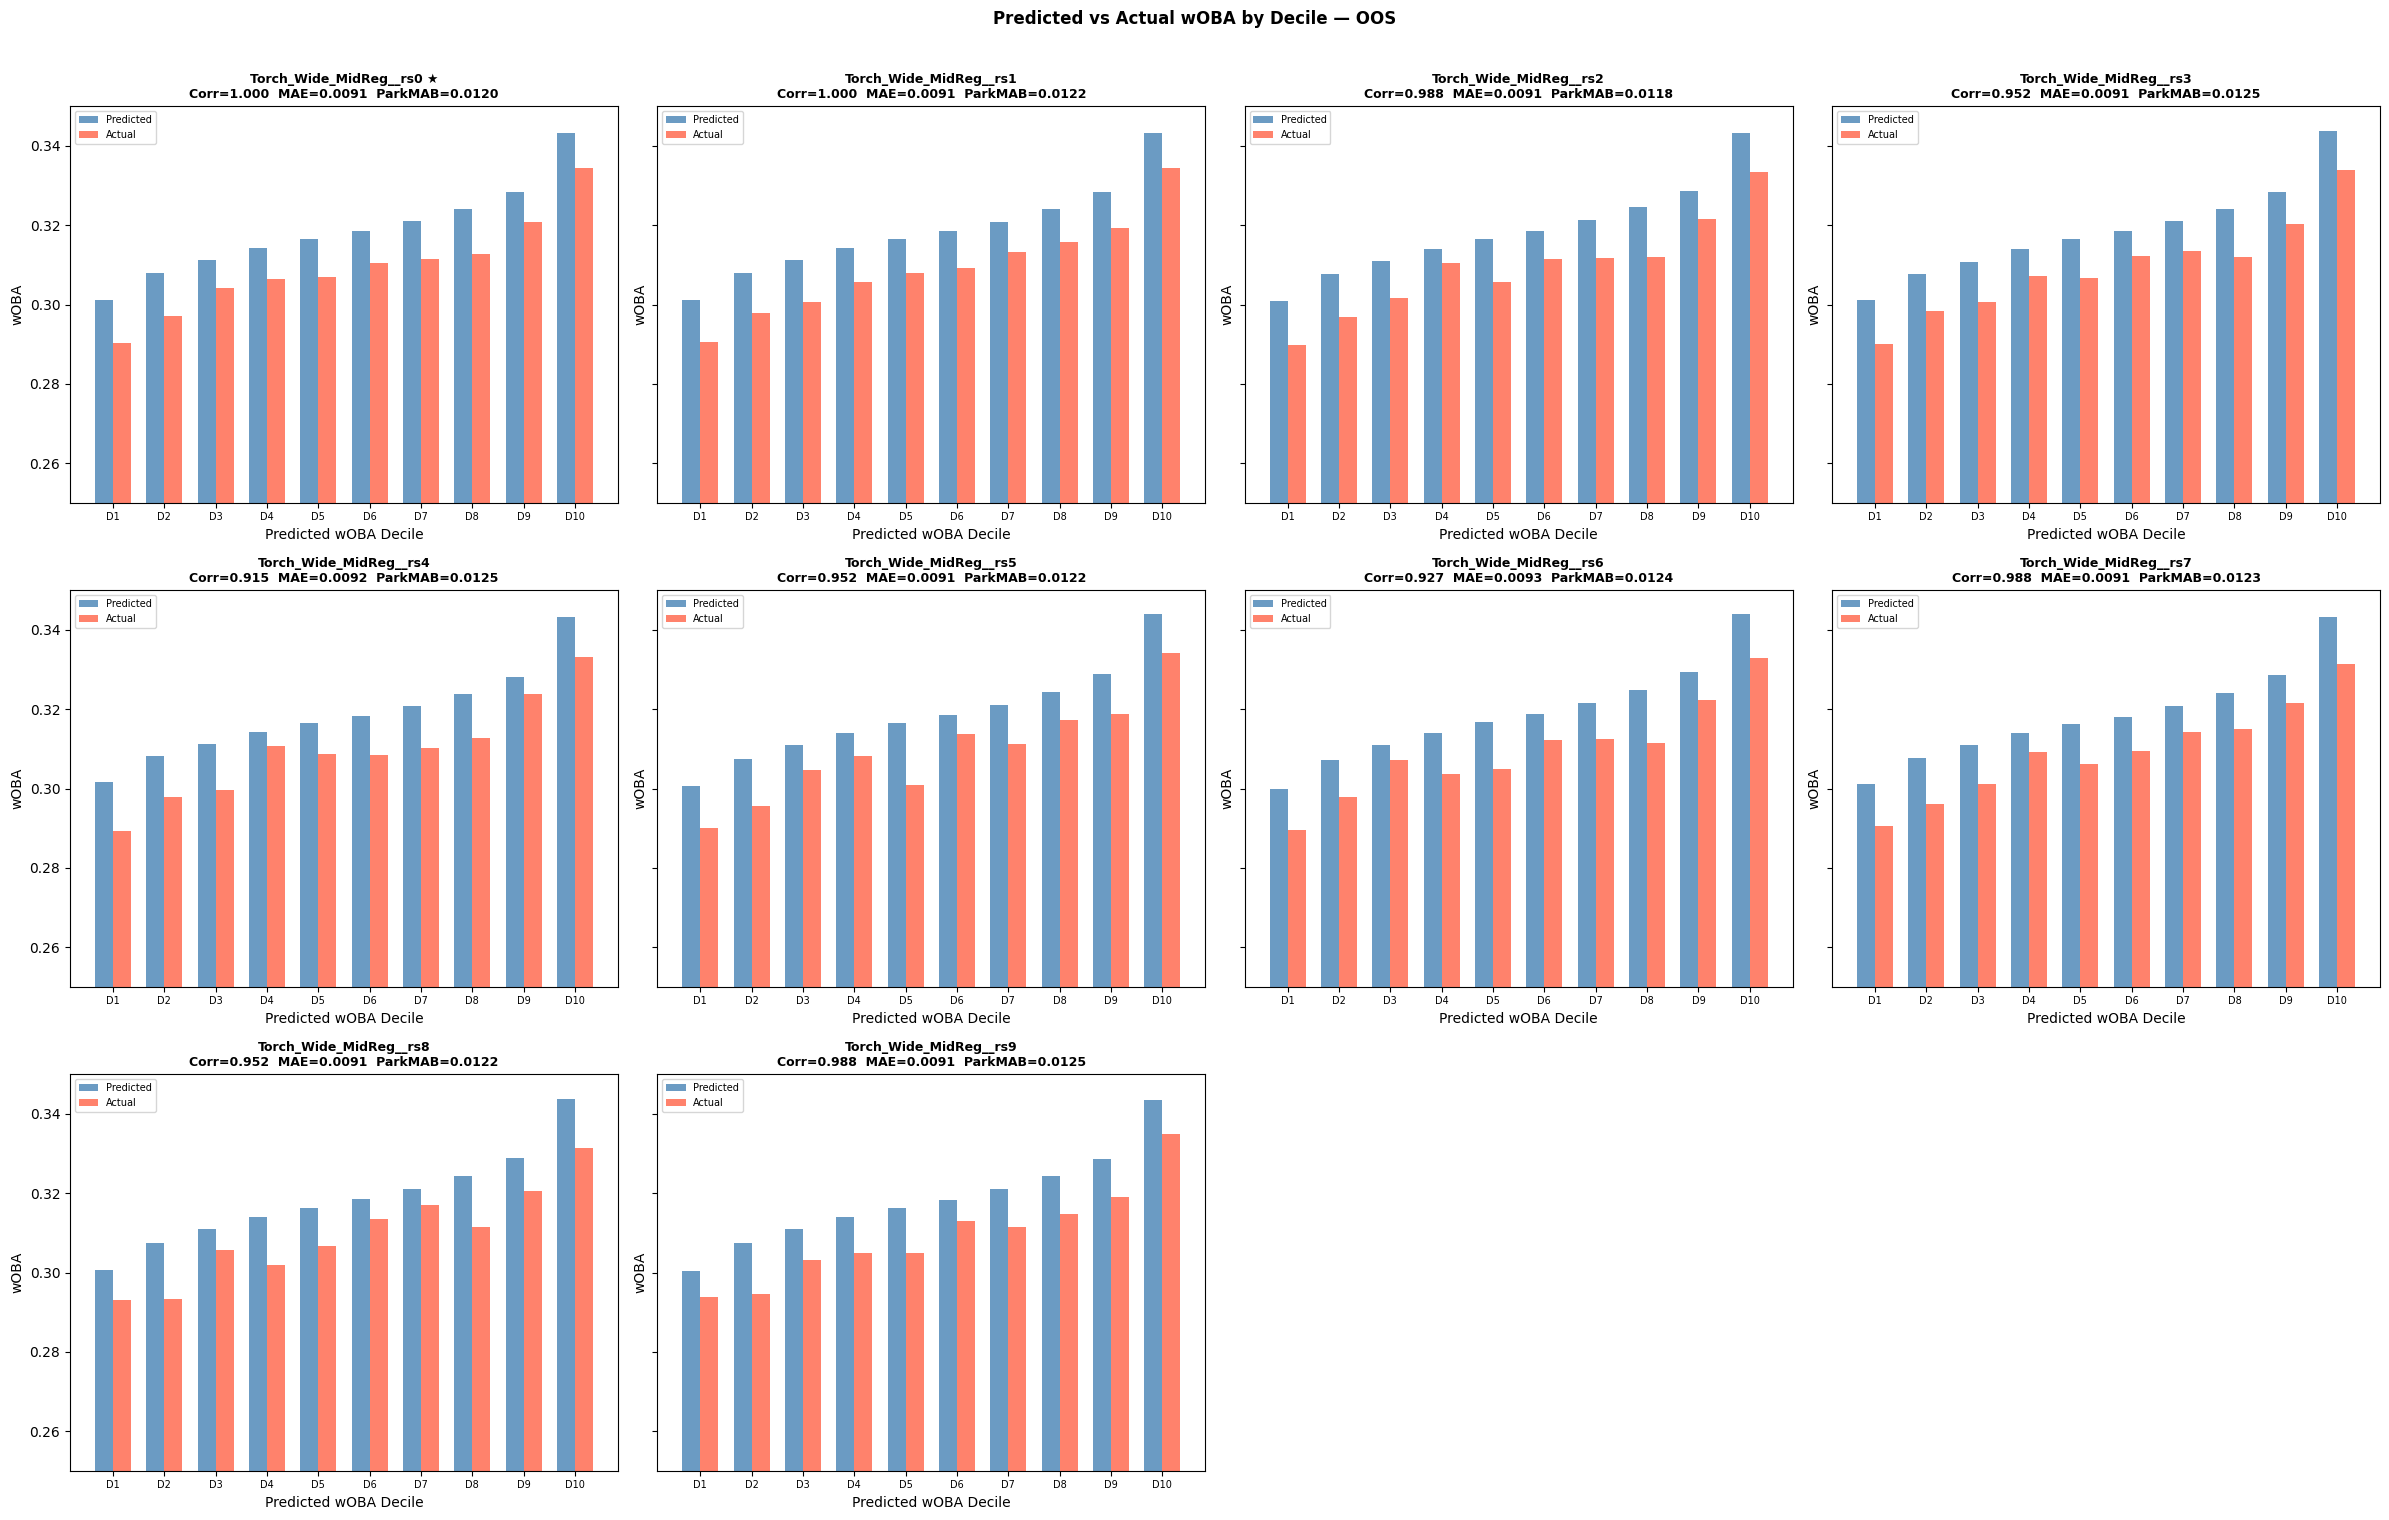

In [38]:
# ============================================================
# Model Comparison — Train / Predict / Evaluate
# Trains several TorchEnsemble configurations, evaluates OOS
# via full wOBA pipeline. The winner is stored as `predict_wfx`.
# Only runs when train_weather_model=True and run directly.
# ============================================================

import warnings
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import spearmanr

# ── 0. Prep ───────────────────────────────────────────────────────────────────
X_train_np = X_train_scaled.values
y_train_np = y_train.values

# ── 1. PyTorch model definition ───────────────────────────────────────────────
class WeatherNet(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_layers, dropout):
        super().__init__()
        layers = []
        in_dim = n_inputs
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, n_outputs))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def train_torch_model(X_train, y_train, device, hidden_layers, dropout,
                      lr, batch_size, weight_decay, epochs=100, patience=5, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    n_val = int(len(X_t) * 0.2)
    X_tr, X_val = X_t[n_val:], X_t[:n_val]
    y_tr, y_val = y_t[n_val:], y_t[:n_val]
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    model = WeatherNet(X_train.shape[1], y_train.shape[1], hidden_layers, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    best_val_loss, best_state, wait = float('inf'), None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val).item()
        if val_loss < best_val_loss:
            best_val_loss, best_state, wait = val_loss, model.state_dict().copy(), 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model

class TorchEnsemble:
    def __init__(self, models, device):
        self.models = models
        self.device = device
    def predict(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            preds = torch.stack([m(X_t) for m in self.models])
        return preds.mean(dim=0).cpu().numpy()

# ── 2. Candidate configurations ───────────────────────────────────────────────
# Each entry: (hidden_layers, dropout, lr, batch_size, weight_decay)
torch_configs = {
    # "Torch_HighReg":         ([64, 32, 16],      0.0, 0.001, 16, 0.05),
    # "Torch_MidReg_B32":      ([64, 32, 16],      0.0, 0.001, 32, 0.03),
    # "Torch_Wide_HighReg":    ([128, 64, 32],      0.0, 0.001, 32, 0.05),
    "Torch_Wide_MidReg":     ([128, 64, 32],      0.0, 0.001, 32, 0.03),
    # "Torch_Wider_HighReg":   ([256, 128, 64],     0.0, 0.001, 32, 0.05),
    # "Torch_Wider_MidReg":    ([64, 32, 16],     0.0, 0.001, 32, 0.03),
    # "Torch_Wider_B64":       ([256, 128, 64],     0.0, 0.001, 64, 0.05),
    # "Torch_Deep_Wide":       ([256, 128, 64, 32], 0.0, 0.001, 32, 0.05),
}

# ── 3. Train (only if run directly and train_weather_model=True) ──────────────
if is_main and train_weather_model:
    # Each "run" is one (config, random_state) pair, trained as its own ensemble.
    # Keyed by a unique run name so the rest of the pipeline can treat runs like
    # it previously treated configs. The base config name is kept for saving.
    trained_models = {}          # run_name -> TorchEnsemble
    run_config_name = {}         # run_name -> base torch_config name
    run_random_state = {}        # run_name -> random_state used
    print(f"Training candidate models ({n_random_states} random state(s) per config)...")
    for name, (hidden_layers, dropout, lr, batch_size, weight_decay) in torch_configs.items():
        for rs in range(n_random_states):
            run_name = f"{name}__rs{rs}" if n_random_states > 1 else name
            models = [train_torch_model(X_train_np, y_train_np, device,
                                        hidden_layers, dropout, lr, batch_size, weight_decay,
                                        seed=rs * 1000 + i)
                      for i in range(ensemble_size)]
            trained_models[run_name] = TorchEnsemble(models, device)
            run_config_name[run_name] = name
            run_random_state[run_name] = rs
            print(f"  ✓ {run_name}  layers={hidden_layers}  dropout={dropout}  lr={lr}  batch={batch_size}  wd={weight_decay}")

    # ── 4. wOBA evaluation pipeline ───────────────────────────────────────────
    woba_weights_eval = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}

    min_venue_games = 50
    venue_game_counts = (game_weather_dataset[game_weather_dataset['date'].astype(str) <= max_training_date].groupby('venue_id_adj').size())
    low_sample_venues = venue_game_counts[venue_game_counts < min_venue_games].index.tolist()

    gwd_scaled = game_weather_dataset.copy()
    for venue_id in low_sample_venues:
        dummy_col = f'venue_{venue_id}'
        if dummy_col in gwd_scaled.columns:
            gwd_scaled[dummy_col] = 0
    gwd_scaled[scale_cols] = scale_wfx.transform(game_weather_dataset[scale_cols])
    X_full_np = gwd_scaled[wfx_inputs].astype(float).values

    train_mask_eval = game_weather_dataset['date'].astype(str) <= max_training_date
    league_avg = {}
    for side in ['L', 'R']:
        side_mask = train_mask_eval & (game_weather_dataset['batSide'] == side)
        league_avg[side] = {e: game_weather_dataset.loc[side_mask, e].mean() for e in woba_weights_eval}

    # Add venue names to eval_df for park bias metric
    venue_map_tmp = venue_map_df[['id', 'name']].copy()
    venue_map_tmp['id'] = venue_map_tmp['id'].astype(str)

    def run_woba_pipeline(model, X_full_np, game_weather_dataset, events_list,
                          woba_weights_eval, league_avg, min_venue_games, max_training_date,
                          min_testing_date, max_testing_date):
        gwd2 = game_weather_dataset.copy()
        log_multiplier_preds = model.predict(X_full_np)

        # Dome/roof mask
        dome_game_mask = gwd2['weather'].str.contains('Roof|Dome', case=False, na=False)

        for i, event in enumerate(events_list):
            gwd2[f'{event}_log_multiplier_pred'] = log_multiplier_preds[:, i]
            gwd2[f'{event}_wfx_unadj'] = np.exp(log_multiplier_preds[:, i])
            scale_df = (
                gwd2[gwd2['date'].astype(str) <= max_training_date]
                .groupby(['venue_id_adj', 'batSide'])
                .apply(lambda x: pd.Series({
                    'scale_factor': x[f'{event}_pfx'].mean() / x[f'{event}_wfx_unadj'].mean(),
                    'n': len(x)
                }))
                .reset_index()
            )
            league_scale = scale_df[scale_df['n'] >= min_venue_games]['scale_factor'].mean()
            scale_df['scale_factor'] = np.where(
                scale_df['n'] >= min_venue_games, scale_df['scale_factor'], league_scale)
            scale_map = scale_df.set_index(['venue_id_adj', 'batSide'])['scale_factor']
            scaled = (
                gwd2[f'{event}_wfx_unadj'] *
                gwd2.set_index(['venue_id_adj', 'batSide']).index.map(scale_map).values
            )
            gwd2[f'{event}_wfx_adj'] = scaled.fillna(gwd2[f'{event}_wfx_unadj'] * league_scale)

            # Override dome/roof games: use pfx directly
            # gwd2.loc[dome_game_mask, f'{event}_wfx_adj']   = gwd2.loc[dome_game_mask, f'{event}_pfx']
            # gwd2.loc[dome_game_mask, f'{event}_wfx_unadj'] = gwd2.loc[dome_game_mask, f'{event}_pfx']

        l_df = gwd2[gwd2['batSide'] == 'L']
        r_df = gwd2[gwd2['batSide'] == 'R']
        wfx_df_tmp = pd.merge(l_df, r_df, on=['venue_id_adj', 'gamePk', 'date'],
                              how='left', suffixes=('_l', '_r'))
        eval_df = wfx_df_tmp[wfx_df_tmp['date'].astype(str).between(min_testing_date, max_testing_date)].copy()
        for side, lg in [('l', 'L'), ('r', 'R')]:
            pred_components, actual_components = [], []
            for event, weight in woba_weights_eval.items():
                eval_df[f'{event}_pred_woba_{side}']   = league_avg[lg][event] * eval_df[f'{event}_wfx_adj_{side}'] * weight
                eval_df[f'{event}_actual_woba_{side}'] = eval_df[f'{event}_{side}'] * weight
                pred_components.append(f'{event}_pred_woba_{side}')
                actual_components.append(f'{event}_actual_woba_{side}')
            eval_df[f'predicted_woba_{side}'] = eval_df[pred_components].sum(axis=1)
            eval_df[f'actual_woba_{side}']    = eval_df[actual_components].sum(axis=1)
        eval_df['predicted_woba'] = eval_df[['predicted_woba_l', 'predicted_woba_r']].mean(axis=1)
        eval_df['actual_woba']    = eval_df[['actual_woba_l',    'actual_woba_r']].mean(axis=1)
        eval_df = eval_df.dropna(subset=['predicted_woba', 'actual_woba'])
        # Add venue names
        eval_df['venue_id'] = eval_df['venue_id_adj'].str.replace(r'[A-Za-z]', '', regex=True)
        eval_df = eval_df.merge(venue_map_tmp, left_on='venue_id', right_on='id', how='left')
        return eval_df

    def woba_metrics(eval_df):
        eval_df = eval_df.copy()

        # Decile metrics
        eval_df['decile'] = pd.qcut(eval_df['predicted_woba'], q=10, labels=False, duplicates='drop')
        summary = eval_df.groupby('decile').agg(
            mean_predicted=('predicted_woba', 'mean'),
            mean_actual=('actual_woba', 'mean')).reset_index()
        corr, _ = spearmanr(summary['mean_predicted'], summary['mean_actual'])
        mae = (summary['mean_predicted'] - summary['mean_actual']).abs().mean()

        # Park quantile bias metric — avoid groupby/apply by using transform + groupby agg
        park_counts = eval_df['name'].value_counts()
        valid_parks = park_counts[park_counts >= 50].index
        park_eval   = eval_df[eval_df['name'].isin(valid_parks)].copy()
        park_eval['park_quantile'] = park_eval.groupby('name')['predicted_woba'].transform(
            lambda x: pd.qcut(x, q=3, labels=[0, 1, 2], duplicates='drop')
        )
        park_eval['bias'] = park_eval['predicted_woba'] - park_eval['actual_woba']
        park_mab = (park_eval.groupby(['name', 'park_quantile'])['bias']
                    .mean().abs()
                    .groupby(level='name').mean()
                    .mean())

        return corr, mae, park_mab, summary

    # ── 5. Evaluate ───────────────────────────────────────────────────────────
    results = {}
    summaries = {}
    print("\nEvaluating OOS (full wOBA pipeline)...")
    for name, model in trained_models.items():
        eval_df = run_woba_pipeline(model, X_full_np, game_weather_dataset, events_list,
                                    woba_weights_eval, league_avg, min_venue_games, max_training_date,
                                    min_testing_date, max_testing_date)
        corr, mae, park_mab, summary = woba_metrics(eval_df)
        results[name] = {'DecileCorr': corr, 'DecileMAE': mae, 'ParkMAB': park_mab}
        summaries[name] = summary
        print(f"  {name:22s}  DecileCorr={corr:.4f}  DecileMAE={mae:.5f}  ParkMAB={park_mab:.5f}")

    # ── 6. Summary table + winner (primary: DecileMAE) ────────────────────────
    # 'Model' here is the per-run key (config + random state). We rank across all
    # runs and keep the single best run, so the best config AND its best seed win.
    results_df = pd.DataFrame(results).T.rename_axis('Model').reset_index()
    results_df['Config']      = results_df['Model'].map(run_config_name)
    results_df['RandomState'] = results_df['Model'].map(run_random_state)
    results_df['AvgRank'] = (
        results_df['DecileMAE'].rank(ascending=True) * 2 +
        results_df['DecileCorr'].rank(ascending=False) * 1 +
        results_df['ParkMAB'].rank(ascending=True) * 2
    ) / 5

    print("\n── Model Comparison (OOS wOBA) — all runs ──────────────────────────────────")
    print(results_df[['Model','Config','RandomState','DecileCorr','DecileMAE','ParkMAB','AvgRank']]
          .sort_values('AvgRank')
          .round({'DecileCorr':4,'DecileMAE':5,'ParkMAB':5,'AvgRank':2}).to_string(index=False))

    # Best random state per config (informational)
    best_per_config = (results_df.sort_values('AvgRank')
                       .groupby('Config', as_index=False).first())
    print("\n── Best run per config ─────────────────────────────────────────────────────")
    print(best_per_config[['Config','RandomState','DecileCorr','DecileMAE','ParkMAB','AvgRank']]
          .sort_values('AvgRank')
          .round({'DecileCorr':4,'DecileMAE':5,'ParkMAB':5,'AvgRank':2}).to_string(index=False))

    best_run_name   = results_df.sort_values('AvgRank').iloc[0]['Model']
    best_model_name = run_config_name[best_run_name]
    best_rs         = run_random_state[best_run_name]
    print(f"\n✓ Best run: {best_run_name}  (config={best_model_name}, random_state={best_rs})")

    # ── 7. Set predict_wfx to the winning run ─────────────────────────────────
    predict_wfx = trained_models[best_run_name]
    print(f"predict_wfx → {best_run_name}")

    # ── 8. Save winning ensemble ───────────────────────────────────────────────
    model_folder = os.path.join(model_path, "M01. Park and Weather Factors", todaysdate)
    os.makedirs(model_folder, exist_ok=True)
    for i, m in enumerate(predict_wfx.models):
        torch.save(m.state_dict(), os.path.join(model_folder, f'predict_wfx_{i}.pt'))
    winning_config = torch_configs[best_model_name]
    pickle.dump({'name': best_model_name, 'run_name': best_run_name,
                 'random_state': best_rs, 'config': winning_config,
                 'n_inputs': X_train_np.shape[1], 'n_outputs': y_train_np.shape[1],
                 'n_models': ensemble_size},
                open(os.path.join(model_folder, 'predict_wfx_config.pkl'), 'wb'))
    print(f"Saved {ensemble_size} model weights + config to {model_folder}")

    # ── 9. Decile charts ───────────────────────────────────────────────────────
    n_models = len(summaries)
    ncols = min(4, n_models)
    nrows = (n_models + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)
    axes = np.array(axes).flatten()

    for ax, (name, summary) in zip(axes, summaries.items()):
        x, w = np.arange(len(summary)), 0.35
        ax.bar(x - w/2, summary['mean_predicted'], w, label='Predicted', color='steelblue', alpha=0.8)
        ax.bar(x + w/2, summary['mean_actual'],    w, label='Actual',    color='tomato',    alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f'D{int(d)+1}' for d in summary['decile']], fontsize=7)
        ax.set_xlabel('Predicted wOBA Decile')
        ax.set_ylabel('wOBA')
        is_best = ' ★' if name == best_run_name else ''
        r = results[name]
        ax.set_title(f'{name}{is_best}\nCorr={r["DecileCorr"]:.3f}  MAE={r["DecileMAE"]:.4f}  ParkMAB={r["ParkMAB"]:.4f}',
                     fontweight='bold', fontsize=9)
        ax.set_ylim(0.25, 0.35)
        ax.legend(fontsize=7)

    for ax in axes[n_models:]:
        ax.set_visible(False)

    plt.suptitle('Predicted vs Actual wOBA by Decile — OOS', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

else:
    # ── Load saved model when skipping training ────────────────────────────────
    model_folder = os.path.join(model_path, "M01. Park and Weather Factors", wfx_date)
    cfg = pickle.load(open(os.path.join(model_folder, 'predict_wfx_config.pkl'), 'rb'))
    hidden_layers, dropout, lr, batch_size, weight_decay = cfg['config']
    n_inputs, n_outputs = cfg['n_inputs'], cfg['n_outputs']
    loaded_models = []
    for i in range(cfg['n_models']):
        m = WeatherNet(n_inputs, n_outputs, hidden_layers, dropout).to(device)
        m.load_state_dict(torch.load(os.path.join(model_folder, f'predict_wfx_{i}.pt'), map_location=device))
        m.eval()
        loaded_models.append(m)
    predict_wfx = TorchEnsemble(loaded_models, device)
    print(f"Loaded saved model: {cfg['name']} from {model_folder}")

##### Predict

Note: We want to run this on the full dataset to get WFX for historic as well as future games

In [39]:
# Identify low-sample venues
min_venue_games = 50
venue_game_counts = (
    game_weather_dataset[game_weather_dataset['date'].astype(str) <= max_training_date]
    .groupby('venue_id_adj')
    .size()
)
low_sample_venues = venue_game_counts[venue_game_counts < min_venue_games].index.tolist()

# Make a copy of the dataframe for WFX predictions
game_weather_dataset2 = game_weather_dataset.copy()

# Zero out venue dummies for low-sample venues before predicting
for venue_id in low_sample_venues:
    dummy_col = f'venue_{venue_id}'
    if dummy_col in game_weather_dataset2.columns:
        game_weather_dataset2[dummy_col] = 0

# Scale
game_weather_dataset2[scale_cols] = scale_wfx.transform(game_weather_dataset[scale_cols])

# Predict log multipliers using the ensemble
log_multiplier_preds = predict_wfx.predict(game_weather_dataset2[wfx_inputs].astype(float).values)

# Return scale_cols to prior values (for reference)
game_weather_dataset2[scale_cols] = game_weather_dataset[scale_cols]

# For games played under roof/dome, set wfx_adj = pfx directly (no weather contribution)
dome_game_mask = game_weather_dataset2['weather'].str.contains('Roof|Dome', case=False, na=False)

# League average scale factor per batSide (fallback for low-sample venues)
league_scale_factors = {}

for i, event in enumerate(events_list):
    game_weather_dataset2[f'{event}_log_multiplier_pred'] = log_multiplier_preds[:, i]
    game_weather_dataset2[f'{event}_wfx_unadj'] = np.exp(log_multiplier_preds[:, i])

    # Compute per-venue scale factor with sample size
    scale_df = (
        game_weather_dataset2[game_weather_dataset2['date'].astype(str) <= max_training_date]
        .groupby(['venue_id_adj', 'batSide'])
        .apply(lambda x: pd.Series({
            'scale_factor': x[f'{event}_pfx'].mean() / x[f'{event}_wfx_unadj'].mean(),
            'n': len(x)
        }))
        .reset_index()
    )

    # League average scale factor for fallback
    league_scale = scale_df[scale_df['n'] >= min_venue_games]['scale_factor'].mean()

    # Use league average for low-sample venues
    scale_df['scale_factor'] = np.where(
        scale_df['n'] >= min_venue_games,
        scale_df['scale_factor'],
        league_scale
    )

    scale_map = scale_df.set_index(['venue_id_adj', 'batSide'])['scale_factor']

    scaled = (
        game_weather_dataset2[f'{event}_wfx_unadj'] *
        game_weather_dataset2.set_index(['venue_id_adj', 'batSide']).index.map(scale_map).values
    )

    # Fall back to league scale for completely new venues
    game_weather_dataset2[f'{event}_wfx_adj'] = scaled.fillna(
        game_weather_dataset2[f'{event}_wfx_unadj'] * league_scale
    )

    # Override dome/roof games: use pfx directly
    # game_weather_dataset2.loc[dome_game_mask, f'{event}_wfx_adj'] = game_weather_dataset2.loc[dome_game_mask, f'{event}_pfx']
    # game_weather_dataset2.loc[dome_game_mask, f'{event}_wfx_unadj'] = game_weather_dataset2.loc[dome_game_mask, f'{event}_pfx']

### Evaluations

Summary Statistics

In [40]:
wfx_cols  = [col for col in game_weather_dataset2.columns if "_wfx_" in col]
game_weather_dataset2[wfx_cols].describe()

,b1_wfx_unadj,b1_wfx_adj,b2_wfx_unadj,b2_wfx_adj,b3_wfx_unadj,b3_wfx_adj,bb_wfx_unadj,bb_wfx_adj,fo_wfx_unadj,fo_wfx_adj,go_wfx_unadj,go_wfx_adj,hbp_wfx_unadj,hbp_wfx_adj,hr_wfx_unadj,hr_wfx_adj,lo_wfx_unadj,lo_wfx_adj,po_wfx_unadj,po_wfx_adj,so_wfx_unadj,so_wfx_adj
count,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000,37832.000000
mean,0.855238,0.982200,0.293895,0.965832,0.074226,1.139772,1.000177,1.000000,0.908930,0.977150,0.996008,1.022512,0.999907,0.999998,0.375475,1.134368,0.465904,0.972285,0.586578,0.994837,0.999992,0.999999
std,0.015740,0.026157,0.037882,0.098380,0.018545,0.429407,0.000023,0.000013,0.009549,0.030390,0.000894,0.013189,0.000006,0.000005,0.037297,0.152667,0.038070,0.048449,0.029274,0.057660,0.000001,0.000002
min,0.786195,0.907131,0.162278,0.550141,0.023207,0.436986,1.000119,0.999943,0.866634,0.864636,0.992382,0.986519,0.999867,0.999959,0.237776,0.667136,0.319837,0.715546,0.466866,0.730659,0.999986,0.999989
25%,0.842277,0.963512,0.262440,0.897948,0.058776,0.850121,1.000159,0.999994,0.901105,0.960518,0.995251,1.014446,0.999904,0.999996,0.344590,1.025273,0.434425,0.947439,0.562500,0.964737,0.999992,0.999999
50%,0.855565,0.982029,0.292328,0.961645,0.072421,1.031305,1.000178,1.000000,0.909099,0.978325,0.996062,1.023341,0.999907,0.999999,0.374448,1.131066,0.465300,0.972989,0.586580,0.999816,0.999992,1.000000
75%,0.867839,0.999527,0.323150,1.020968,0.087853,1.326977,1.000193,1.000005,0.916563,0.993953,0.996705,1.031266,0.999911,1.000001,0.404609,1.236995,0.495782,1.000136,0.609768,1.028088,0.999993,1.000000
max,0.896068,1.063528,0.403682,1.717997,0.135020,2.934366,1.000293,1.000101,0.933454,1.085607,0.998435,1.050709,0.999931,1.000026,0.480450,1.730646,0.570971,1.248827,0.664679,1.205703,0.999997,1.000005


Park Outliers

In [41]:
# Sort and get top/bottom 500
top_500 = game_weather_dataset2.nlargest(500, 'hr_wfx_unadj')
bottom_500 = game_weather_dataset2.nsmallest(500, 'hr_wfx_unadj')

# Get value counts
top_counts = top_500['venue_id_adj'].value_counts().head(5).reset_index()
bottom_counts = bottom_500['venue_id_adj'].value_counts().head(5).reset_index()
top_counts.columns = ['Top Venue', 'Top Count']
bottom_counts.columns = ['Bottom Venue', 'Bottom Count']

result_df = pd.concat([top_counts, bottom_counts], axis=1)
result_df

,Top Venue,Top Count,Bottom Venue,Bottom Count
0,19,356,17,163
1,17,86,2680,119
2,7A,45,680,54
3,3,8,3,36
4,15,4,4,23


Best Home Run Games

In [42]:
game_weather_dataset2.sort_values('hr_wfx_unadj', ascending=False).head(100)[['hr_wfx_unadj', 'meteo_y_vect', 'temperature_2m']].mean()

hr_wfx_unadj      0.479045
meteo_y_vect      1.639060
temperature_2m   86.030356
dtype: float64

Worst Home Run Games

In [43]:
game_weather_dataset2.sort_values('hr_wfx_unadj', ascending=False).tail(100)[['meteo_y_vect', 'temperature_2m']].mean()

meteo_y_vect     -12.852861
temperature_2m    54.949415
dtype: float64

##### WFX Dataframe

Convert from long to wide

In [44]:
l_shifted_game_wfx_df = game_weather_dataset2[game_weather_dataset2['batSide'] == "L"]
r_shifted_game_wfx_df = game_weather_dataset2[game_weather_dataset2['batSide'] == "R"]

wfx_df = pd.merge(l_shifted_game_wfx_df, r_shifted_game_wfx_df, on=['venue_id_adj', 'gamePk', 'date'], how='left', suffixes=("_l", "_r"))

Add venue name

In [45]:
wfx_df['venue_id'] = wfx_df['venue_id_adj'].str.replace(r'[A-Za-z]', '', regex=True)
venue_map_df['id'] = venue_map_df['id'].astype(str)
wfx_df = wfx_df.merge(venue_map_df[['id', 'name']], left_on='venue_id_adj', right_on='id', how='left')

Venue Rankings

In [46]:
wfx_df[wfx_df['date'].astype(str) >= '20220101'].groupby(['name', 'venue_id_adj'])[['hr_wfx_unadj_l', 'hr_wfx_unadj_r', 'hr_wfx_adj_l', 'hr_wfx_adj_r', 'hr_pfx_l', 'hr_pfx_r']].mean().sort_values('hr_pfx_r', ascending=False)

,,hr_wfx_unadj_l,hr_wfx_unadj_r,hr_wfx_adj_l,hr_wfx_adj_r,hr_pfx_l,hr_pfx_r
name,venue_id_adj,,,,,,
Great American Ball Park,2602,0.354328,0.407642,1.516469,1.418947,1.380429,1.253582
UNIQLO Field at Dodger Stadium,22,0.329293,0.384804,1.298708,1.291602,1.133591,1.207404
Sutter Health Park,2529,0.349382,0.409563,1.283738,1.183936,1.284041,1.184393
George M. Steinbrenner Field,2523,0.344881,0.404920,1.044198,1.156616,1.044198,1.156616
Citizens Bank Park,2681,0.352502,0.411436,1.250540,1.246005,1.188031,1.154511
Daikin Park,2392,0.342852,0.400218,1.291580,1.284596,1.103516,1.149140
American Family Field,32,0.350924,0.408235,1.361411,1.225236,1.278144,1.127977
Coors Field,19,0.401983,0.466245,1.393369,1.249881,1.166131,1.121490
Tropicana Field,12,0.346577,0.405841,1.193403,1.146388,1.036489,1.102581


##### Out of Sample

 decile  mean_predicted  mean_actual   n
      0        0.301100     0.290200 361
      1        0.307900     0.297000 361
      2        0.311100     0.304100 361
      3        0.314300     0.306500 361
      4        0.316500     0.306900 361
      5        0.318400     0.310600 361
      6        0.321000     0.311500 361
      7        0.324100     0.312800 361
      8        0.328400     0.320700 361
      9        0.343400     0.334300 361


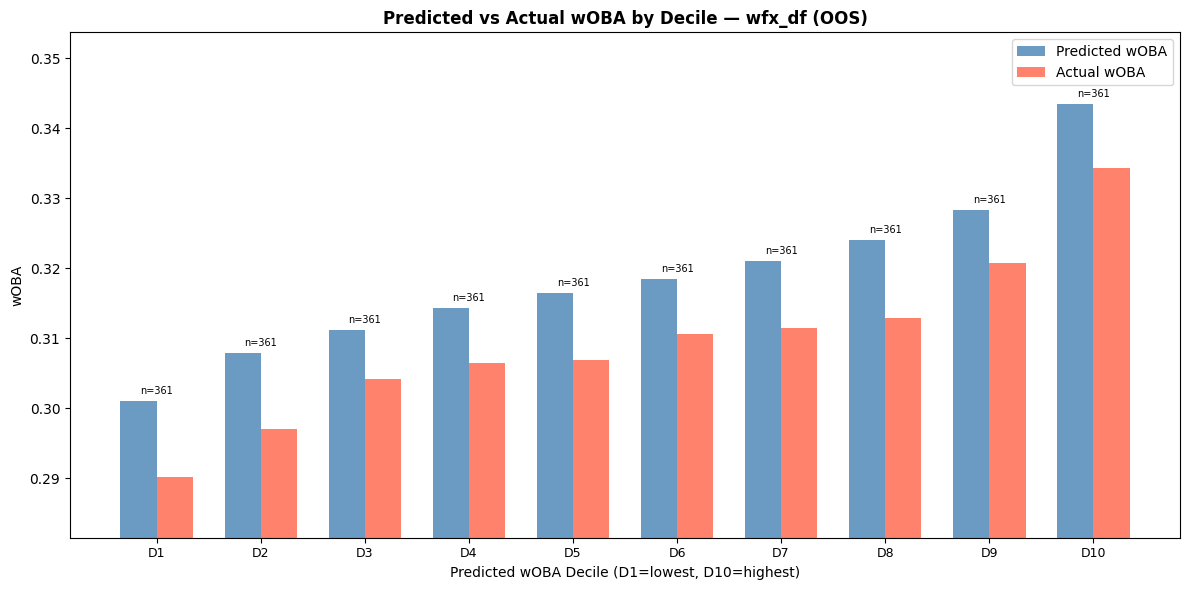

In [47]:
woba_weights = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}

# ── Compute wOBA on wfx_df ────────────────────────────────────────────────────
# wfx_df is in wide format (L and R side by side), so handle each side separately
eval_df = wfx_df[wfx_df['date'].astype(str).between(min_testing_date, max_testing_date)].copy()
# eval_df = wfx_df[wfx_df['date'].astype(str) <= max_training_date].copy()

league_avg_l = wfx_df[wfx_df['date'].astype(str) <= max_training_date][[f'{e}_l' for e in woba_weights]].mean()
league_avg_r = wfx_df[wfx_df['date'].astype(str) <= max_training_date][[f'{e}_r' for e in woba_weights]].mean()

for side, league_avg in [('l', league_avg_l), ('r', league_avg_r)]:
    pred_components = []
    actual_components = []
    for event, weight in woba_weights.items():
        pred_col   = f'{event}_wfx_adj_{side}'
        actual_col = f'{event}_{side}'
        eval_df[f'{event}_pred_woba_{side}']   = league_avg[f'{event}_{side}'] * eval_df[pred_col] * weight
        eval_df[f'{event}_actual_woba_{side}'] = eval_df[actual_col] * weight
        pred_components.append(f'{event}_pred_woba_{side}')
        actual_components.append(f'{event}_actual_woba_{side}')
    eval_df[f'predicted_woba_{side}'] = eval_df[pred_components].sum(axis=1)
    eval_df[f'actual_woba_{side}']    = eval_df[actual_components].sum(axis=1)

# Average L and R into single game-level wOBA
eval_df['predicted_woba'] = eval_df[['predicted_woba_l', 'predicted_woba_r']].mean(axis=1)
eval_df['actual_woba']    = eval_df[['actual_woba_l', 'actual_woba_r']].mean(axis=1)

# ── Decile bucketing ──────────────────────────────────────────────────────────
eval_df = eval_df.dropna(subset=['predicted_woba', 'actual_woba'])
eval_df['decile'] = pd.qcut(eval_df['predicted_woba'], q=10, labels=False, duplicates='drop')

summary = (
    eval_df.groupby('decile')
    .agg(
        mean_predicted=('predicted_woba', 'mean'),
        mean_actual=('actual_woba', 'mean'),
        n=('actual_woba', 'count')
    )
    .reset_index()
)

print(summary.round(4).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary))
width = 0.35

ax.bar(x - width/2, summary['mean_predicted'], width,
       label='Predicted wOBA', color='steelblue', alpha=0.8)
ax.bar(x + width/2, summary['mean_actual'], width,
       label='Actual wOBA', color='tomato', alpha=0.8)

for i, row in summary.iterrows():
    ax.text(i, max(row['mean_predicted'], row['mean_actual']) + 0.001,
            f'n={int(row["n"])}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f'D{int(d)+1}' for d in summary['decile']], fontsize=9)
ax.set_xlabel('Predicted wOBA Decile (D1=lowest, D10=highest)')
ax.set_ylabel('wOBA')
ax.set_title('Predicted vs Actual wOBA by Decile — wfx_df (Out of Sample)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(summary[['mean_predicted', 'mean_actual']].min().min() * 0.97,
            summary[['mean_predicted', 'mean_actual']].max().max() * 1.03)

plt.tight_layout()
plt.show()

##### Historic

 decile  mean_predicted  mean_actual    n
      0        0.300600     0.296800 1892
      1        0.308100     0.304700 1892
      2        0.311400     0.306500 1891
      3        0.314500     0.310400 1892
      4        0.316700     0.310200 1891
      5        0.318600     0.316400 1892
      6        0.321000     0.312900 1891
      7        0.324000     0.316100 1892
      8        0.329700     0.320600 1891
      9        0.345700     0.340700 1892


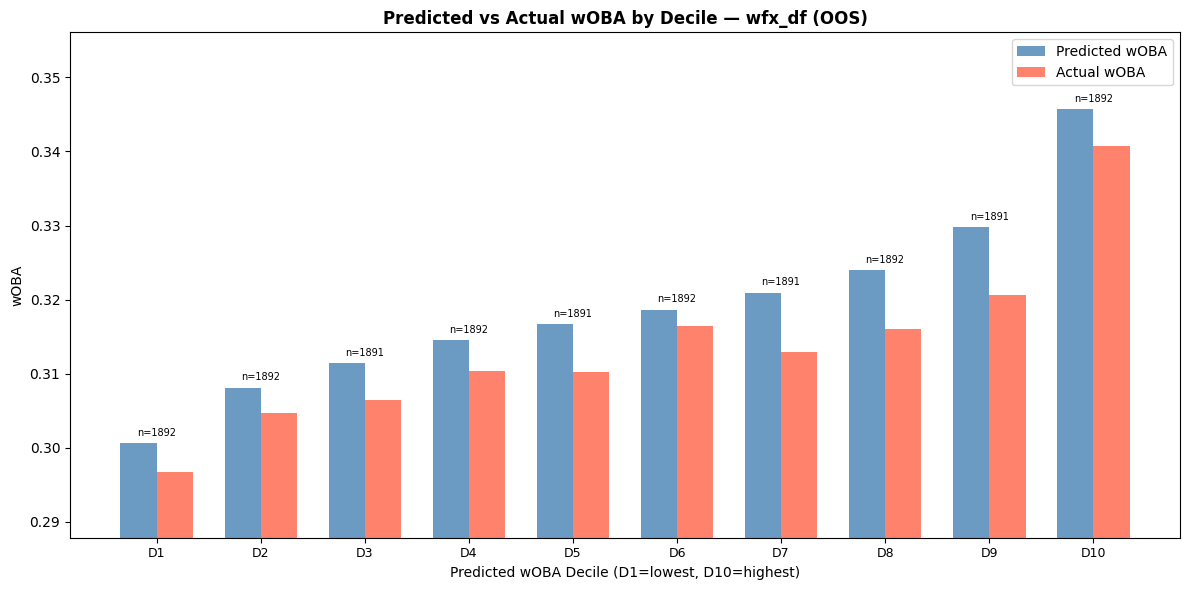

In [48]:
woba_weights = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}

# ── Compute wOBA on wfx_df ────────────────────────────────────────────────────
# wfx_df is in wide format (L and R side by side), so handle each side separately
eval_df = wfx_df.copy()
# eval_df = wfx_df[wfx_df['date'].astype(str) <= max_training_date].copy()

league_avg_l = wfx_df[wfx_df['date'].astype(str) <= max_training_date][[f'{e}_l' for e in woba_weights]].mean()
league_avg_r = wfx_df[wfx_df['date'].astype(str) <= max_training_date][[f'{e}_r' for e in woba_weights]].mean()

for side, league_avg in [('l', league_avg_l), ('r', league_avg_r)]:
    pred_components = []
    actual_components = []
    for event, weight in woba_weights.items():
        pred_col   = f'{event}_wfx_adj_{side}'
        actual_col = f'{event}_{side}'
        eval_df[f'{event}_pred_woba_{side}']   = league_avg[f'{event}_{side}'] * eval_df[pred_col] * weight
        eval_df[f'{event}_actual_woba_{side}'] = eval_df[actual_col] * weight
        pred_components.append(f'{event}_pred_woba_{side}')
        actual_components.append(f'{event}_actual_woba_{side}')
    eval_df[f'predicted_woba_{side}'] = eval_df[pred_components].sum(axis=1)
    eval_df[f'actual_woba_{side}']    = eval_df[actual_components].sum(axis=1)

# Average L and R into single game-level wOBA
eval_df['predicted_woba'] = eval_df[['predicted_woba_l', 'predicted_woba_r']].mean(axis=1)
eval_df['actual_woba']    = eval_df[['actual_woba_l', 'actual_woba_r']].mean(axis=1)

# ── Decile bucketing ──────────────────────────────────────────────────────────
eval_df = eval_df.dropna(subset=['predicted_woba', 'actual_woba'])
eval_df['decile'] = pd.qcut(eval_df['predicted_woba'], q=10, labels=False, duplicates='drop')

summary = (
    eval_df.groupby('decile')
    .agg(
        mean_predicted=('predicted_woba', 'mean'),
        mean_actual=('actual_woba', 'mean'),
        n=('actual_woba', 'count')
    )
    .reset_index()
)

print(summary.round(4).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary))
width = 0.35

ax.bar(x - width/2, summary['mean_predicted'], width,
       label='Predicted wOBA', color='steelblue', alpha=0.8)
ax.bar(x + width/2, summary['mean_actual'], width,
       label='Actual wOBA', color='tomato', alpha=0.8)

for i, row in summary.iterrows():
    ax.text(i, max(row['mean_predicted'], row['mean_actual']) + 0.001,
            f'n={int(row["n"])}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f'D{int(d)+1}' for d in summary['decile']], fontsize=9)
ax.set_xlabel('Predicted wOBA Decile (D1=lowest, D10=highest)')
ax.set_ylabel('wOBA')
ax.set_title('Predicted vs Actual wOBA by Decile — wfx_df (In Sample)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(summary[['mean_predicted', 'mean_actual']].min().min() * 0.97,
            summary[['mean_predicted', 'mean_actual']].max().max() * 1.03)

plt.tight_layout()
plt.show()

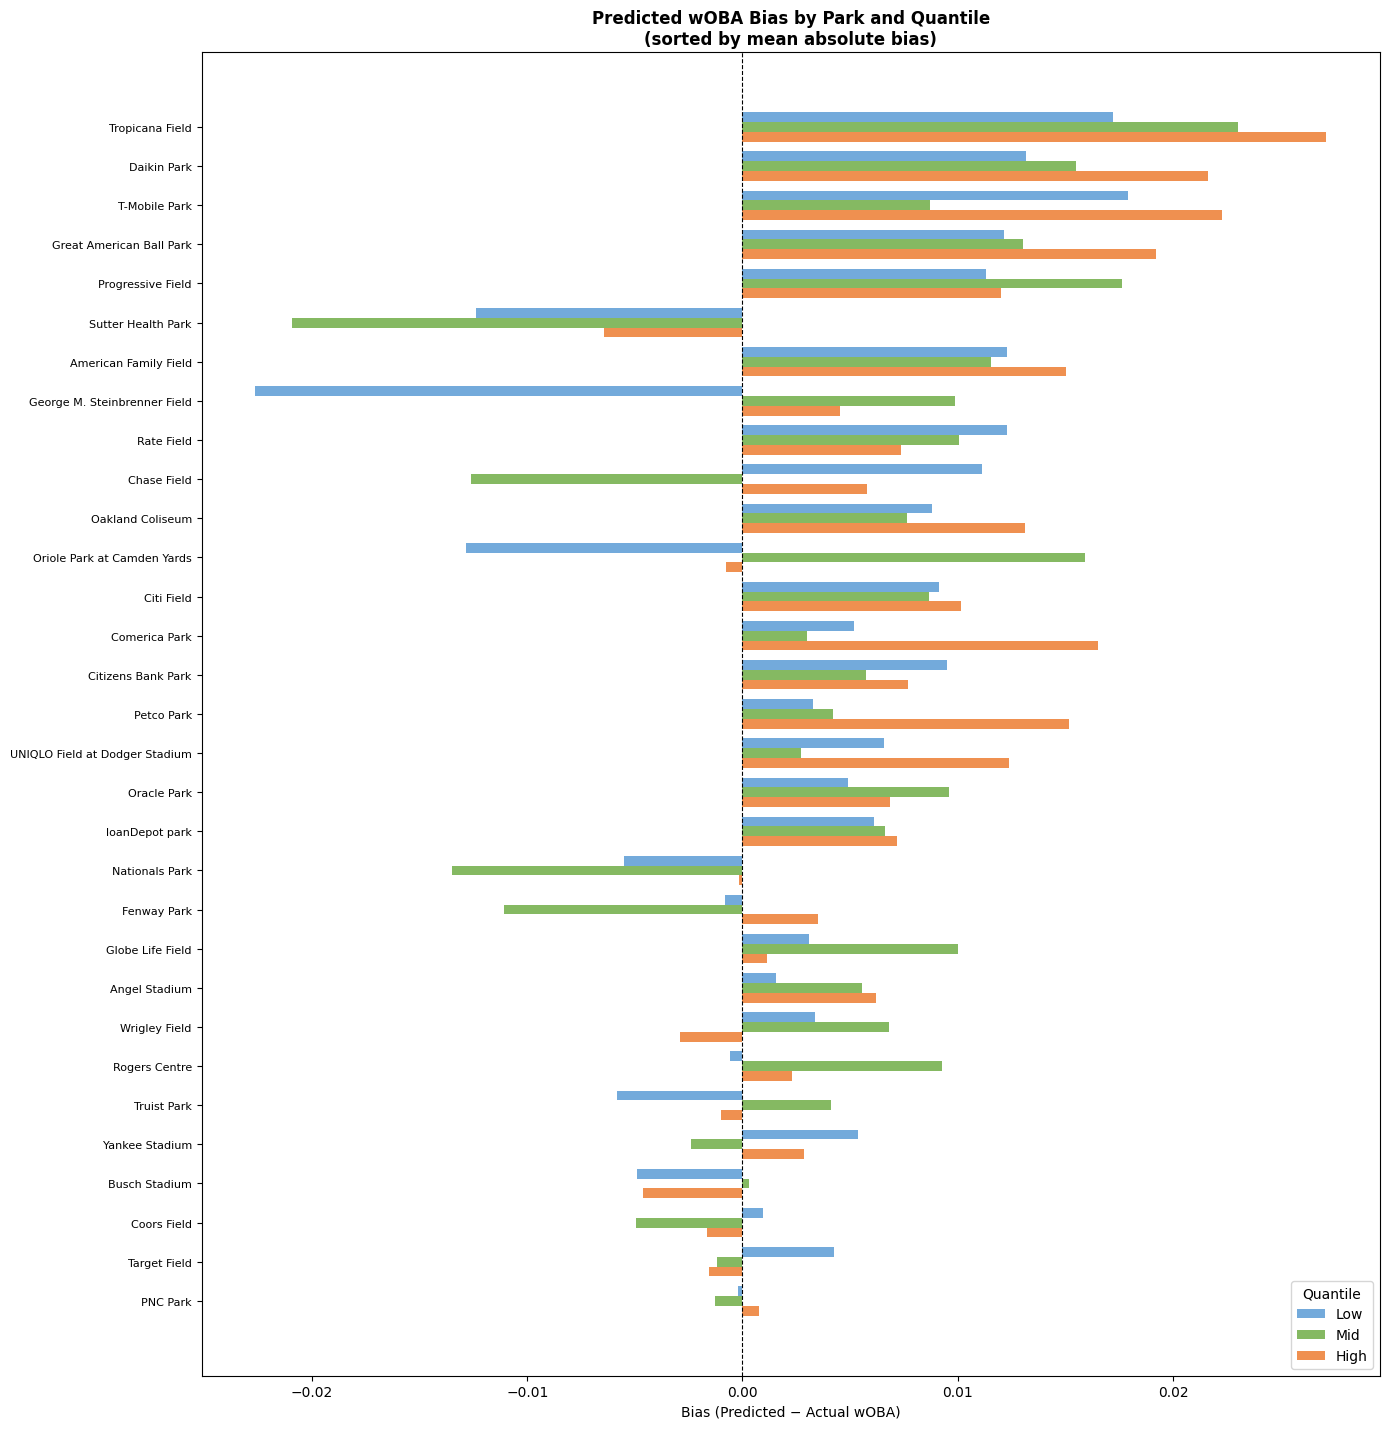


── Park Bias Summary (min 50 games) ──────────────────────────────────────
                                     Low       Mid      High    n
name                                                             
Tropicana Field                 0.017200  0.023000  0.027100  559
Daikin Park                     0.013200  0.015500  0.021600  638
T-Mobile Park                   0.017900  0.008700  0.022300  631
Great American Ball Park        0.012100  0.013000  0.019200  630
Progressive Field               0.011300  0.017600  0.012000  638
Sutter Health Park             -0.012400 -0.020900 -0.006400  116
American Family Field           0.012300  0.011600  0.015000  641
George M. Steinbrenner Field   -0.022600  0.009900  0.004500   76
Rate Field                      0.012300  0.010100  0.007400  633
Chase Field                     0.011100 -0.012600  0.005800  634
Oakland Coliseum                0.008800  0.007700  0.013100  513
Oriole Park at Camden Yards    -0.012800  0.015900 -0.000700  127


In [49]:
# ── Park Performance Analysis ─────────────────────────────────────────────────
woba_weights_park = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}
min_park_games = 50

# Build game-level eval_df (all historical games)
eval_all = wfx_df.copy()

league_avg_l_park = wfx_df[wfx_df['date'].astype(str) <= max_training_date][[f'{e}_l' for e in woba_weights_park]].mean()
league_avg_r_park = wfx_df[wfx_df['date'].astype(str) <= max_training_date][[f'{e}_r' for e in woba_weights_park]].mean()

for side, league_avg in [('l', league_avg_l_park), ('r', league_avg_r_park)]:
    pred_components, actual_components = [], []
    for event, weight in woba_weights_park.items():
        eval_all[f'{event}_pred_woba_{side}']   = league_avg[f'{event}_{side}'] * eval_all[f'{event}_wfx_adj_{side}'] * weight
        eval_all[f'{event}_actual_woba_{side}'] = eval_all[f'{event}_{side}'] * weight
        pred_components.append(f'{event}_pred_woba_{side}')
        actual_components.append(f'{event}_actual_woba_{side}')
    eval_all[f'predicted_woba_{side}'] = eval_all[pred_components].sum(axis=1)
    eval_all[f'actual_woba_{side}']    = eval_all[actual_components].sum(axis=1)

eval_all['predicted_woba'] = eval_all[['predicted_woba_l', 'predicted_woba_r']].mean(axis=1)
eval_all['actual_woba']    = eval_all[['actual_woba_l',    'actual_woba_r']].mean(axis=1)
eval_all = eval_all.dropna(subset=['predicted_woba', 'actual_woba', 'name'])

# Restrict to parks with sufficient sample
park_counts = eval_all['name'].value_counts()
valid_parks  = park_counts[park_counts >= min_park_games].index
eval_all     = eval_all[eval_all['name'].isin(valid_parks)]

# Assign predicted wOBA quantile within each park
eval_all['park_quantile'] = eval_all.groupby('name')['predicted_woba'].transform(
    lambda x: pd.qcut(x, q=3, labels=['Low', 'Mid', 'High'], duplicates='drop')
)

# Bias = mean predicted - mean actual, per park per quantile
park_bias = (
    eval_all.groupby(['name', 'park_quantile'])
    .apply(lambda x: pd.Series({
        'bias': x['predicted_woba'].mean() - x['actual_woba'].mean(),
        'n': len(x)
    }))
    .reset_index()
)


# ── Plot: bias by quantile for each park ──────────────────────────────────────
bias_pivot = park_bias.pivot(index='name', columns='park_quantile', values='bias').reindex(columns=['Low', 'Mid', 'High'])
bias_pivot = bias_pivot.loc[bias_pivot.abs().mean(axis=1).sort_values(ascending=False).index]


park_bias_n = eval_all.groupby('name').size().rename('n')
bias_pivot = bias_pivot.join(park_bias_n)

fig, ax = plt.subplots(figsize=(14, len(bias_pivot) * 0.4 + 2))

x   = np.arange(len(bias_pivot))
w   = 0.25
colors = {'Low': '#5b9bd5', 'Mid': '#70ad47', 'High': '#ed7d31'}

for j, q in enumerate(['Low', 'Mid', 'High']):
    ax.barh(x + j * w, bias_pivot[q], w, label=q, color=colors[q], alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(x + w)
ax.set_yticklabels(bias_pivot.index, fontsize=8)
ax.set_xlabel('Bias (Predicted − Actual wOBA)')
ax.set_title('Predicted wOBA Bias by Park and Quantile\n(sorted by mean absolute bias)',
             fontweight='bold')
ax.legend(title='Quantile', loc='lower right')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n── Park Bias Summary (min {min_park_games} games) ──────────────────────────────────────")
print(bias_pivot.round(4).to_string())

### Create Clean Weather Columns

In [50]:
for col in ['weather', 'meteo_x_vect', 'meteo_y_vect', 'temperature_2m']:
    wfx_df[col] = wfx_df[f'{col}_l'].copy()

### Write

All Games

In [51]:
wfx_df[['venue_id_adj', 'gamePk', 'date'] + ['weather', 'meteo_x_vect', 'meteo_y_vect', 'temperature_2m'] + [col for col in wfx_df if "wfx" in col] + [col for col in wfx_df if "pred" in col] + [f'{event}_l' for event in events_list] + [f'{event}_r' for event in events_list]].to_csv(
    os.path.join(baseball_path, "Park and Weather Factors.csv"), index=False)

Individual Games

In [52]:
for date in wfx_df['date'].unique():
    wfx_df[wfx_df['date'] == date][['venue_id_adj', 'gamePk', 'date'] + ['weather', 'meteo_x_vect', 'meteo_y_vect', 'temperature_2m'] + [col for col in wfx_df if "wfx" in col]].to_csv(os.path.join(baseball_path, "B02. WFX", f"Park and Weather Factors {date}.csv"), index=False)